# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Syahrani.R
- **Email:** cdcc304d6x1444@student.devacademy.id
- **ID Dicoding:** CDCC304D6X1444

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana distribusi penyewaan sepeda per jamnya dan apakah terdapat perbedaan pola antara hari kerja dan hari libur?
- Pertanyaan 2 : Sejauh mana kondisi cuaca dan suhu udara memengaruhi total penyewaan sepeda setiap harinya?

## Import Semua Packages/Library yang Digunakan

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [33]:
day_df = pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [34]:
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset ini diperoleh dari program Coding Camp (bersumber dari Kaggle) dalam format CSV yang terdiri dari dua tabel utama, yaitu day_df (day.csv : 16 kolom) untuk data harian dan hour_df (hour.csv : 17 kolom) untuk data per jam. Perbedaan utama terletak pada kolom hr yang hanya tersedia di tabel per jam  untuk menunjukkan waktu pencatatan (0-23)
- Melihat dari karakteristik variabel. Data mencakup informasi kronologis (tanggal, musim, bulan, tahun), kondisi lingkungan (cuaca, suhu, kelembapan, kecepatan angin yang telah dinormalisasi), serta status hari (hari libur atau hari kerja). Variabel target utama adalah cnt, yang merupakan total penyewaan sepeda hasil penggabungan antara pengguna pengguna tipe casual (tidak terdaftar) dan registered (terdaftar).

### Assessing Data

In [35]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [36]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [37]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [38]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [39]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [40]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [41]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())
hour_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Berdasarkan pengecekan menggunakan fungsi isna().sum() dan duplicated().sum(), tidak ditemukan adanya missing values (data hilang) maupun data duplikat pada day_df (731 entri) dan hour_df (17.379 entri). Selain itu, pengecekan statistik deskriptif menunjukkan tidak ada inaccurate value, di mana variabel numerik seperti temp, atemp, hum, dan windspeed telah ternormalisasi sesuai dokumentasi.
- Teridentifikasi adanya masalah pada tipe data di kedua dataset, di mana kolom dteday masih terdeteksi sebagai object dan kolom kategorikal (seperti season, mnth, holiday, weekday, workingday, dan weathersit) masih bertipe int64. Perbaikan tipe data menjadi datetime dan category sangat diperlukan pada tahap cleaning guna menjamin akurasi analisis dan kerapian visualisasi data nantinya.

### Cleaning Data

In [42]:
datetime_columns = ["dteday"]
for columns in datetime_columns:
  day_df[columns] = pd.to_datetime(day_df[columns])

In [43]:
category_columns = ["season", "mnth", "holiday", "weekday", "workingday", "weathersit"]
for columns in category_columns:
  day_df[columns] = day_df[columns].astype('category')

In [44]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    category      
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    category      
 5   holiday     731 non-null    category      
 6   weekday     731 non-null    category      
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    category      
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: category(6), datetime64

In [45]:
datetime_columns = ["dteday"]
for columns in datetime_columns:
  hour_df[columns] = pd.to_datetime(hour_df[columns])

In [46]:
category_columns = ["season", "mnth", "holiday", "weekday", "workingday", "weathersit"]
for columns in category_columns:
  hour_df[columns] = hour_df[columns].astype('category')

In [47]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  category      
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  category      
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  category      
 7   weekday     17379 non-null  category      
 8   workingday  17379 non-null  category      
 9   weathersit  17379 non-null  category      
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Kolom dteday pada day_df dan hour_df dikonversi dari object menjadi datetime64 untuk memungkinkan pengolahan data berbasis waktu yang akurat. Penggunaan tipe ini jauh lebih baik daripada object karena memungkinkan kita mengekstraksi komponen waktu secara otomatis dan memastikan urutan kronologis yang benar saat melakukan analisis tren penyewaan.
- Kolom kategorikal seperti season, mnth, holiday, weekday, workingday, dan weathersit diubah dari int64 menjadi category untuk memastikan library visualisasi memperlakukan data sebagai label kelompok (diskrit), bukan angka kontinu, sehingga grafik menjadi lebih rapi. Tipe category dipilih dibandingkan object karena jauh lebih hemat memori, terbukti dengan penurunan penggunaan memori pada day_df menjadi 62.8 KB dan juga pada hour_df menjadi 1.6 MB.

In [48]:
day_df.to_csv("day_clean.csv", index=False)
hour_df.to_csv("hour_clean.csv", index=False)

## Exploratory Data Analysis (EDA)

### Explore ...

In [49]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.0,731.000000,731.0,731.0,731.0,731.0,731.0,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4.0,NaN,12.0,2.0,7.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,3.0,NaN,1.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188.0,NaN,62.0,710.0,105.0,500.0,463.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,0.500684,NaN,NaN,NaN,NaN,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


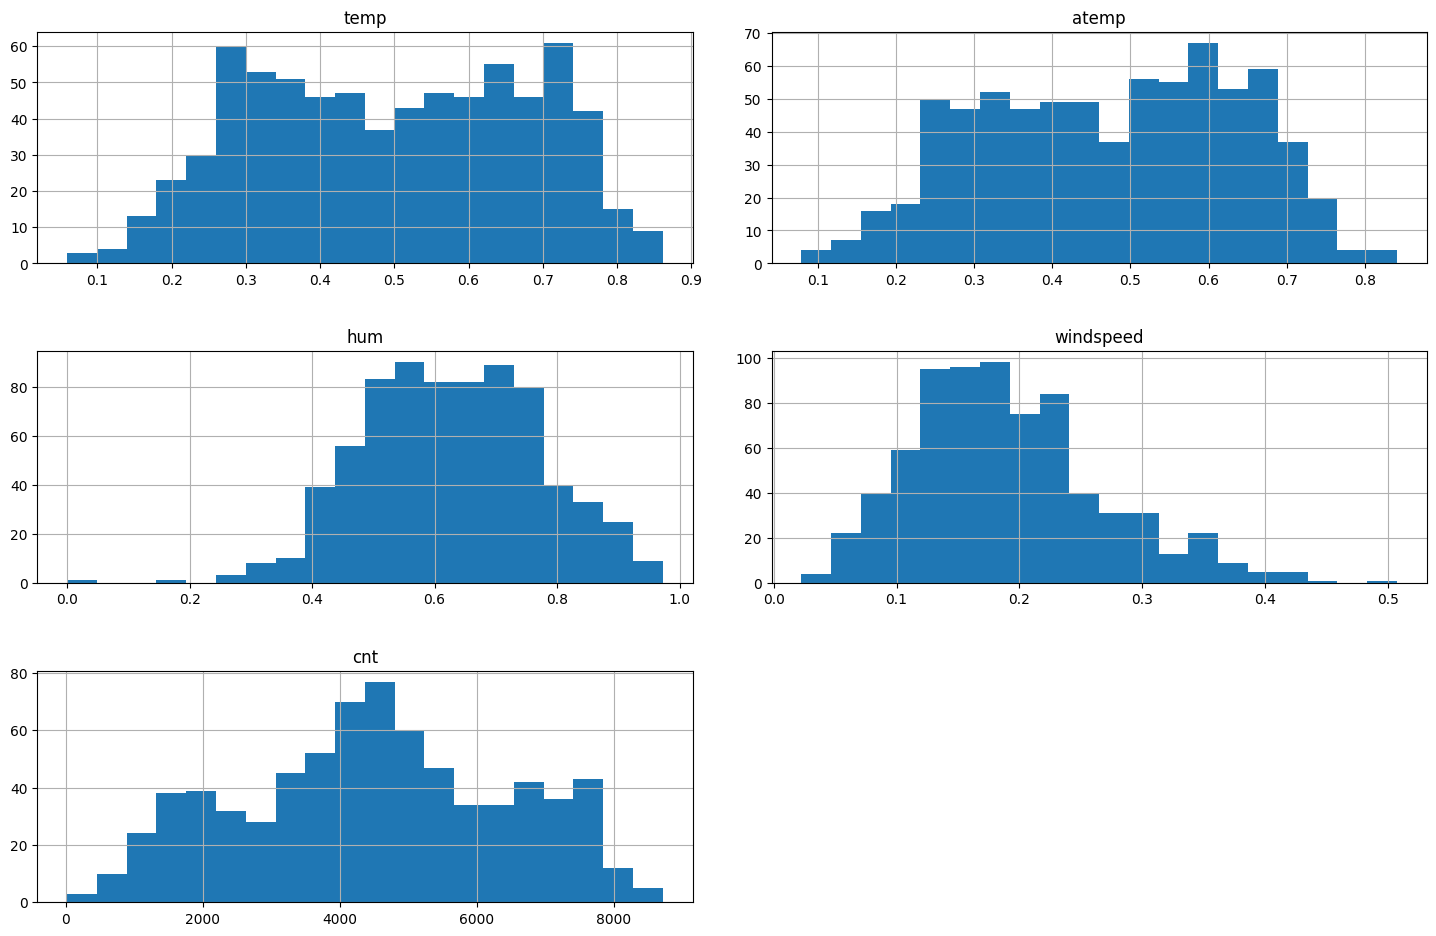

In [50]:
columns_to_plot = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
day_df[columns_to_plot].hist(figsize=(15, 10), bins=20)
plt.tight_layout(pad=3.0)
plt.show()

In [51]:
day_df.groupby(by="weathersit", observed=False).agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "std"]
})

instant   cnt                               
           nunique   max  min         mean          std
weathersit                                             
1              463  8714  431  4876.786177  1879.483989
2              247  8362  605  4035.862348  1809.109918
3               21  4639   22  1803.285714  1240.284449

In [52]:
day_df.groupby(by="season", observed=False).agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "std"]
})

instant   cnt                                
       nunique   max   min         mean          std
season                                              
1          181  7836   431  2604.132597  1399.942119
2          184  8362   795  4992.331522  1695.977235
3          188  8714  1115  5644.303191  1459.800381
4          178  8555    22  4728.162921  1699.615261

In [53]:
day_df[['temp', 'atemp', 'hum', 'cnt']].corr()

,temp,atemp,hum,cnt
temp,1.000000,0.991702,0.126963,0.627494
atemp,0.991702,1.000000,0.139988,0.631066
hum,0.126963,0.139988,1.000000,-0.100659
cnt,0.627494,0.631066,-0.100659,1.000000


In [54]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.0,17379.000000,17379.0,17379.000000,17379.0,17379.0,17379.0,17379.0,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4.0,NaN,12.0,NaN,2.0,7.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,3.0,NaN,7.0,NaN,0.0,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496.0,NaN,1488.0,NaN,16879.0,2512.0,11865.0,11413.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,0.502561,NaN,11.546752,NaN,NaN,NaN,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,0.000000,NaN,6.000000,NaN,NaN,NaN,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,1.000000,NaN,12.000000,NaN,NaN,NaN,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,1.000000,NaN,18.000000,NaN,NaN,NaN,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,1.000000,NaN,23.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


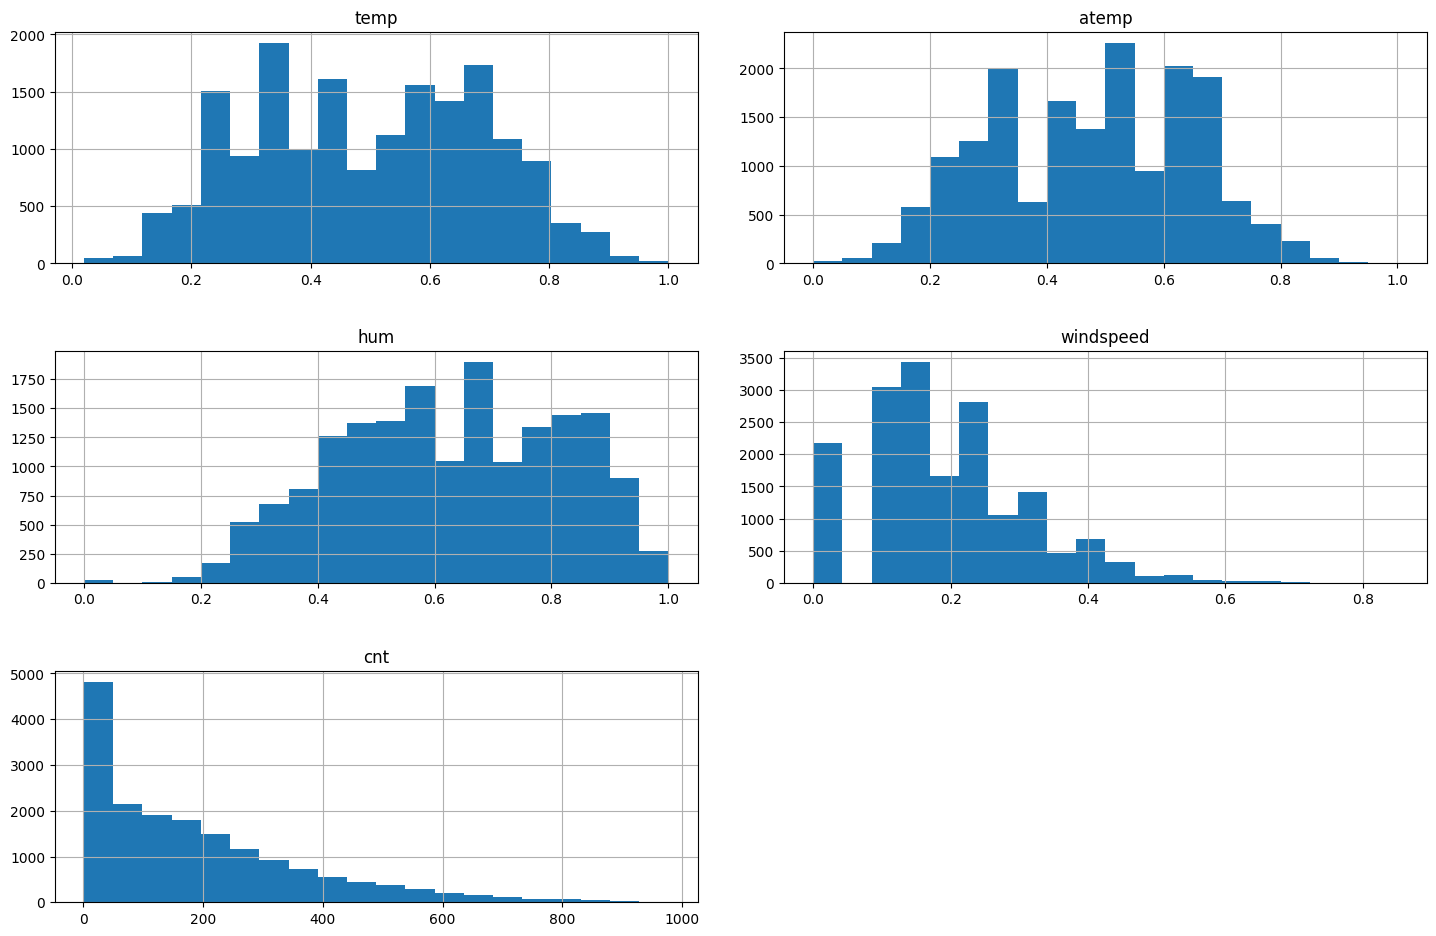

In [55]:
columns_to_plot = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
hour_df[columns_to_plot].hist(figsize=(15, 10), bins=20)
plt.tight_layout(pad=3.0)
plt.show()

In [56]:
hour_df.groupby(by="hr", observed=False).agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "std"]
}).sort_values(by=("cnt", "mean"), ascending=False)

instant  cnt                            
   nunique  max min        mean         std
hr                                         
17     730  976  15  461.452055  232.656611
18     728  977  23  425.510989  224.639304
8      727  839   5  359.011004  235.189285
16     730  783  11  311.983562  148.682618
19     728  743  11  311.523352  161.050359
13     729  760  11  253.661180  148.107657
12     728  776   3  253.315934  145.081134
15     729  750   7  251.233196  144.632541
14     729  750  12  240.949246  147.271574
20     728  567  11  226.030220  119.670164
9      727  426  14  219.309491   93.703458
7      727  596   1  212.064649  161.441936
11     727  663  10  208.143054  127.495536
10     727  539   8  173.668501  102.205413
21     728  584   6  172.314560   89.788893
22     728  502   9  131.335165   69.937782
23     728  256   2   87.831044   50.846889
6      725  213   1   76.044138   55.084348
0      726  283   2   53.898072   42.307910
1      724  168   1   33.375691   33.538727
2      715  132   1   22.869930   26.578642
5      717   66   1   19.889819   13.200765
3      697   79   1   11.727403   13.239190
4      697   28   1    6.352941    4.143818

In [57]:
hour_df.groupby(by="workingday", observed=False).agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "std"]
})

instant  cnt                            
           nunique  max min        mean         std
workingday                                         
0             5514  783   1  181.405332  172.853832
1            11865  977   1  193.207754  185.107477

In [58]:
hour_df.groupby(by=["workingday", "hr"], observed=False).agg({
    "cnt": ["mean", "sum"]
})

cnt        
                     mean     sum
workingday hr                    
0          0    90.800000   20884
           1    69.508696   15987
           2    53.171053   12123
           3    25.775330    5851
           4     8.264317    1876
           5     8.689189    1929
           6    18.742358    4292
           7    43.406926   10027
           8   105.653680   24406
           9   171.623377   39645
           10  255.909091   59115
           11  315.316017   72838
           12  366.259740   84606
           13  372.731602   86101
           14  364.645022   84233
           15  358.813853   82886
           16  352.727273   81480
           17  323.549784   74740
           18  281.056522   64643
           19  231.673913   53285
           20  174.739130   40190
           21  142.060870   32674
           22  116.060870   26694
           23   85.930435   19764
1          0    36.786290   18246
           1    16.552632    8177
           2     8.683778    4229
           3     4.942553    2323
           4     5.429787    2552
           5    24.913131   12332
           6   102.500000   50840
           7   290.612903  144144
           8   477.006048  236595
           9   241.518145  119793
           10  135.366935   67142
           11  158.229839   78482
           12  200.820926   99808
           13  198.429719   98818
           14  183.572289   91419
           15  201.331325  100263
           16  293.122244  146268
           17  525.290581  262120
           18  492.226908  245129
           19  348.401606  173504
           20  249.718876  124360
           21  186.287149   92771
           22  138.389558   68918
           23   88.708835   44177

**Insight:**
- Aktivitas penyewaan sepeda menunjukkan perbedaan perilaku yang kontras antara hari kerja dan hari libur; pada hari kerja, terdapat pola "dua puncak" yang signifikan pada pukul 08.00 dan 17.00 - 18.00 yang mengindikasikan penggunaan sebagai transportasi rutin (komuter), sedangkan pada hari libur, aktivitas lebih bersifat rekreasi dengan lonjakan penyewaan yang terpusat di tengah hari hingga sore hari (pukul 12.00 - 16.00).
- Performa penyewaan sangat bergantung pada kondisi eksternal, di mana rata-rata penyewaan tertinggi terjadi pada cuaca Cerah (Category 1) dan menurun drastis saat hujan/salju, didukung oleh korelasi positif suhu (temp) terhadap jumlah penyewa; selain itu, distribusi data penyewaan yang cenderung right-skewed menunjukkan bahwa meski mayoritas penyewaan berada di angka rata-rata, terdapat hari-hari tertentu dengan lonjakan permintaan yang sangat ekstrem.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

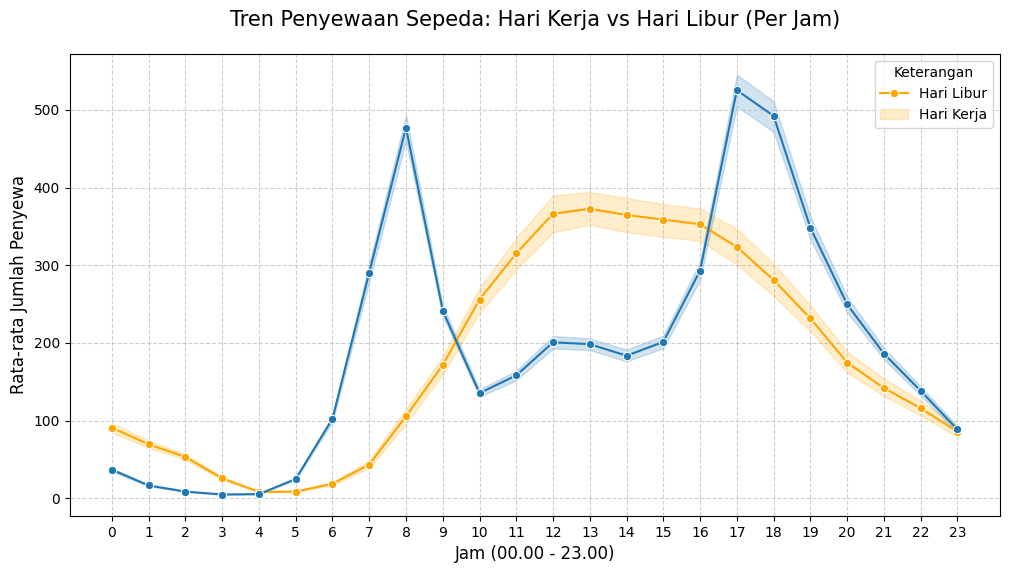

In [59]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    x="hr",
    y="cnt",
    hue="workingday",
    data=hour_df,
    palette=["#FFA500", "#1f77b4"],
    marker='o'
)

plt.title("Tren Penyewaan Sepeda: Hari Kerja vs Hari Libur (Per Jam)", fontsize=15, pad=20)
plt.xlabel("Jam (00.00 - 23.00)", fontsize=12)
plt.ylabel("Rata-rata Jumlah Penyewa", fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title="Keterangan", labels=["Hari Libur", "Hari Kerja"])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Pertanyaan 2:

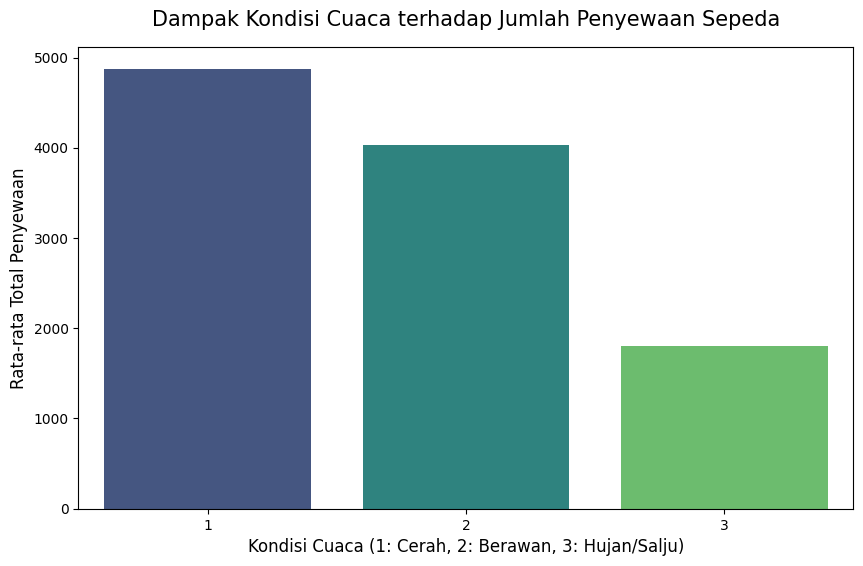

In [60]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="weathersit",
    y="cnt",
    data=day_df,
    hue="weathersit",
    palette="viridis",
    legend=False,
    errorbar=None
)


plt.title("Dampak Kondisi Cuaca terhadap Jumlah Penyewaan Sepeda", fontsize=15, pad=15)
plt.xlabel("Kondisi Cuaca (1: Cerah, 2: Berawan, 3: Hujan/Salju)", fontsize=12)
plt.ylabel("Rata-rata Total Penyewaan", fontsize=12)
plt.show()

**Insight:**
- Visualisasi line chart menunjukkan perbedaan perilaku yang signifikan antara kedua tipe hari. Pada hari kerja, terdapat dua puncak (puncak ganda) penyewaan yang sangat tajam, yaitu pada pukul 08.00 dan 17.00 - 18.00, yang mengukuhkan hipotesis bahwa sepeda digunakan sebagai moda transportasi komuter. Sebaliknya, pada hari libur, grafik menunjukkan pola kurva tunggal yang landai di mana penyewaan mulai meningkat pada pukul 10.00 dan mencapai puncaknya di siang hari (pukul 12.00 - 15.00), mencerminkan aktivitas rekreasi yang lebih santai.
- Grafik batang (bar chart) mengonfirmasi bahwa faktor cuaca merupakan penentu utama volume penyewaan. Terdapat penurunan drastis jumlah penyewa seiring memburuknya cuaca. Penyewaan paling optimal terjadi pada kondisi Cuaca 1 (Cerah/Berawan). Saat beralih ke Cuaca 2 (Mendung/Kabut), terjadi penurunan yang stabil, dan angka tersebut anjlok secara signifikan pada Cuaca 3 (Hujan/Salju Ringan). Hal ini menunjukkan bahwa operasional bisnis sangat sensitif terhadap perubahan atmosfer harian.

## Analisis Lanjutan (Opsional)

In [61]:
usage_patterns = hour_df.groupby(by="hr", observed=False).agg({
    "casual": "mean",
    "registered": "mean"
})

print("--- Rata-rata Pengguna Casual vs Registered per Jam ---")
print(usage_patterns.sort_values(by="registered", ascending=False).head())

--- Rata-rata Pengguna Casual vs Registered per Jam ---
       casual  registered
hr                       
17  74.273973  387.178082
18  61.120879  364.390110
8   21.679505  337.331499
19  48.770604  262.752747
16  73.745205  238.238356


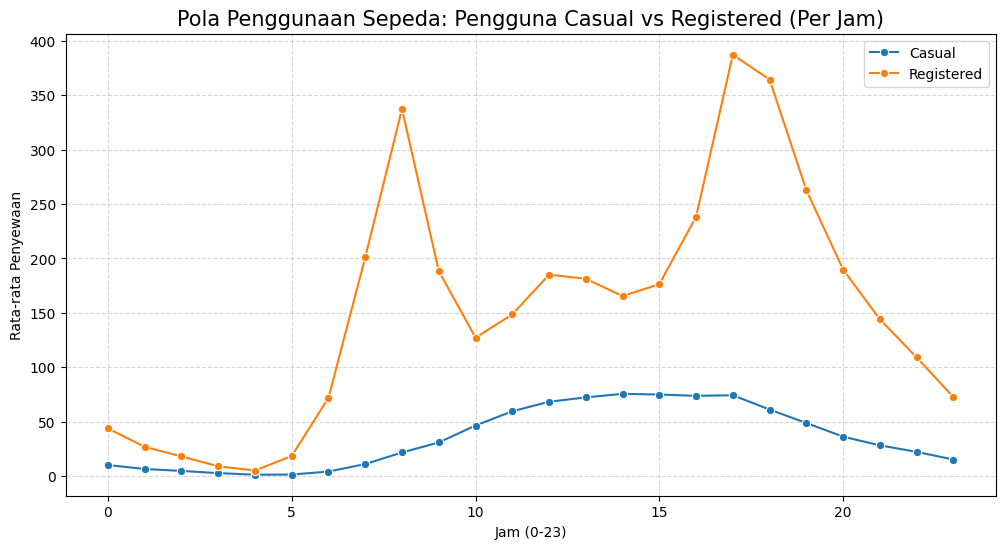

In [62]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=usage_patterns.index, y=usage_patterns['casual'], label='Casual', marker='o')
sns.lineplot(x=usage_patterns.index, y=usage_patterns['registered'], label='Registered', marker='o')

plt.title("Pola Penggunaan Sepeda: Pengguna Casual vs Registered (Per Jam)", fontsize=15)
plt.xlabel("Jam (0-23)")
plt.ylabel("Rata-rata Penyewaan")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Analisis lanjutan menggunakan analisis segmentasi berdasarkan tipe pengguna.
**Insight :**
- Grafik menunjukkan bahwa jumlah pengguna Registered jauh lebih mendominasi dibandingkan pengguna Casual. Pola penggunaan mereka memiliki korelasi yang sangat kuat dengan jam operasional kantor/sekolah, dengan lonjakan tajam pada pukul 08.00 dan 17.00 - 18.00. Hal ini mengindikasikan bahwa kelompok ini adalah pelanggan loyal yang menggunakan layanan sepeda sebagai kebutuhan transportasi utama sehari-hari (komuter).
- Berbeda dengan pengguna terdaftar, pengguna Casual tidak menunjukkan lonjakan tajam pada jam berangkat kerja. Aktivitas mereka mulai meningkat secara perlahan sejak pukul 10.00 pagi dan mencapai puncaknya di sore hari (sekitar pukul 14.00 - 17.00). Pola kurva yang lebih landai dan stabil di siang hari ini mencerminkan penggunaan untuk tujuan rekreasi, wisata, atau aktivitas non-rutin lainnya.
- Terdapat perbedaan volume yang sangat kontras antara kedua segmen. Hal ini memberikan peluang bisnis untuk mengonversi pengguna Casual menjadi Registered melalui program loyalitas atau promosi khusus pada jam-jam siang hari (saat pengguna Casual aktif), guna meningkatkan basis pelanggan tetap dan memaksimalkan penggunaan armada sepeda di luar jam sibuk komuter.
Analisis ini membuktikan bahwa strategi pengelolaan armada harus diprioritaskan untuk menjamin ketersediaan sepeda bagi pengguna terdaftar di jam sibuk, sembari melakukan kampanye pemasaran yang menyasar segmen kasual pada waktu siang hari.

## Conclusion

- Conclution pertanyaan 1 : Berdasarkan hasil analisis, distribusi penyewaan sepeda sangat dipengaruhi oleh waktu dan tipe hari. Pada hari kerja, pola penyewaan bersifat bimodal (memiliki dua puncak) yang terjadi pada jam sibuk, yaitu pukul 08.00 dan 17.00 - 18.00, yang menunjukkan penggunaan utama untuk transportasi komuter. Sebaliknya, pada hari libur, pola penyewaan lebih terdistribusi di tengah hari antara pukul 10.00 hingga 16.00, yang mengindikasikan penggunaan untuk aktivitas rekreasi. Hal ini diperkuat oleh analisis lanjutan yang menunjukkan bahwa pengguna terdaftar (registered) mendominasi jam sibuk, sementara pengguna kasual lebih aktif di siang hari pada akhir pekan.
- Conclution pertanyaan 2 : Faktor lingkungan memiliki pengaruh signifikan terhadap keputusan pengguna untuk menyewa sepeda. Penyewaan mencapai titik maksimal pada kondisi cuaca cerah atau sedikit berawan (Category 1) dan mengalami penurunan drastis seiring dengan meningkatnya intensitas hujan atau salju. Selain itu, terdapat korelasi positif antara suhu (temp) dan jumlah penyewaan; semakin hangat suhu udara (hingga batas tertentu), semakin tinggi volume penyewaan. Secara keseluruhan, cuaca yang ekstrem dan suhu yang terlalu dingin menjadi penghambat utama bagi pengguna dalam menggunakan layanan penyewaan sepeda.